<a href="https://colab.research.google.com/github/Giihgallicchio/Programacao-em-Python-Data-Science/blob/main/An%C3%A1lise_Preditiva.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Regessão Linear Simples: Uma variável explicativa
A Empresa está interessada em verificar se a remuneração dos seus colaboradores está de acordo com as políticas vigentes. Para isso, coletou uma amostra de 46 colaboradores.

**Pergunta de Negócio: ** O Salário muda de acordo com os anos de educação superior? Se sim, é possivel construir um modelo que estime o salário de acordo esses anos?

In [ ]:
# Pacotes de Manipulação de dados
import pandas as pd
import numpy as np

# Pacotes Gráficos
import matplotlib.pyplot as plt
import seaborn as sns

# Pacotes de Modelagem
import statsmodels.api as sm

In [ ]:
df = pd.read_csv('base_funcionarios_v1.csv',
                  sep=';',
                 index_col='id')
df.head()

,Salario,Anos_Educ_Superior
id,,
1,5517.4,3
2,6399.9,4
3,6206.7,6
4,6060.6,4
5,6122.7,2


# Análise Exploratória

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 46 entries, 1 to 46
Data columns (total 2 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Salario             46 non-null     float64
 1   Anos_Educ_Superior  46 non-null     int64  
dtypes: float64(1), int64(1)
memory usage: 1.1 KB


In [ ]:
df.shape

(46, 2)

In [ ]:
df.describe()

,Salario,Anos_Educ_Superior
count,46.000000,46.000000
mean,6969.797826,5.065217
std,1924.868873,2.839422
min,4139.500000,0.000000
25%,5818.350000,4.000000
50%,6394.750000,5.000000
75%,7972.400000,6.000000
max,12118.100000,12.000000


In [ ]:
df.isnull().sum()

,0
Salario,0
Anos_Educ_Superior,0


In [ ]:
df.duplicated().sum()

0

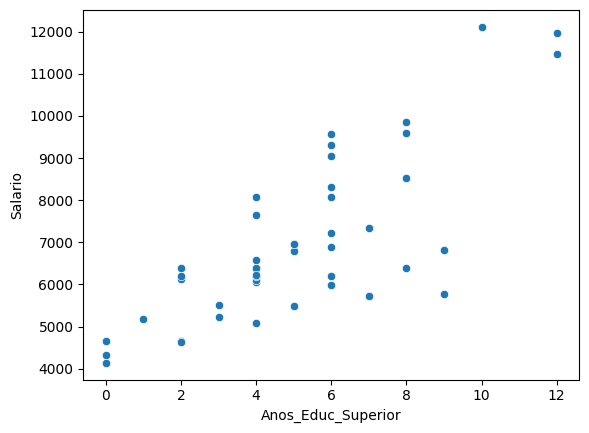

In [ ]:
# Gráfico de Dispersão
sns.scatterplot(x=df['Anos_Educ_Superior'],
                y=df['Salario']);

In [ ]:
# Análise de Correlação Linear de Pearson
df.corr()

,Salario,Anos_Educ_Superior
Salario,1.000000,0.776992
Anos_Educ_Superior,0.776992,1.000000


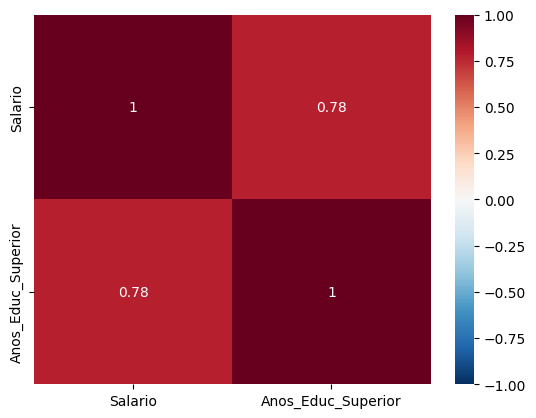

In [ ]:
# Gráfico Heatmap - Correlação Linear de Pearson
sns.heatmap(df.corr(),
           cmap = 'RdBu_r',
            vmin=-1, vmax=1,
            annot=True);

### Ajuste do Modelo de Regressão usando a biblioteca Statsmodels

In [ ]:
# Variável respota
y = df['Salario']

# Variável explicativa
df['intercepto'] = 1
x = df[ ['intercepto','Anos_Educ_Superior'] ]


In [ ]:
# Ajuste do Modelo
modelo = sm.OLS(y,x)
resultado = modelo.fit()

In [ ]:
# Valor de r² ajustado
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     67.03
Date:                Sat, 21 Dec 2024   Prob (F-statistic):           2.18e-10
Time:                        15:33:58   Log-Likelihood:                -391.36
No. Observations:                  46   AIC:                             786.7
Df Residuals:                      44   BIC:                             790.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercepto          4301.7990    372

In [ ]:
df = pd.read_csv('base_funcionarios_v2.csv',
                  sep=';',
                 index_col='id')
df.head()

,Salario,Anos_Educ_Superior,Tempo_Empresa
id,,,
1,5517.4,3,3
2,6399.9,4,6
3,6206.7,6,3
4,6060.6,4,5
5,6122.7,2,9


In [ ]:
df.corr()

,Salario,Anos_Educ_Superior,Tempo_Empresa
Salario,1.000000,0.776992,0.765173
Anos_Educ_Superior,0.776992,1.000000,0.607486
Tempo_Empresa,0.765173,0.607486,1.000000


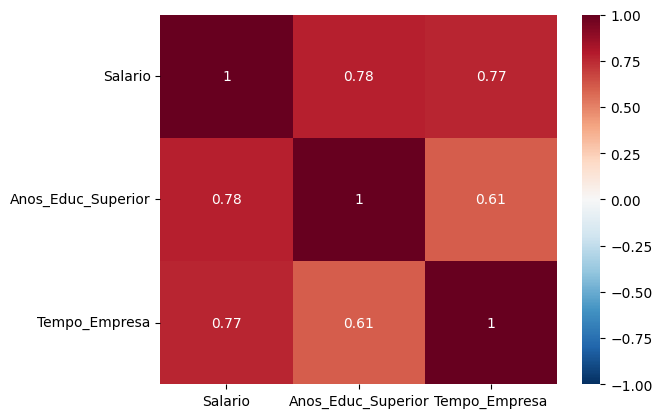

In [ ]:
sns.heatmap(df.corr(),
           cmap = 'RdBu_r',
            vmin=-1, vmax=1,
            annot=True);

In [ ]:
y = df['Salario']
df['intercepto'] = 1
x = df[ ['intercepto','Anos_Educ_Superior', 'Tempo_Empresa'] ]

In [ ]:
modelo = sm.OLS(y,x)
resultado = modelo.fit()
print(resultado.summary())

                            OLS Regression Results                            
Dep. Variable:                Salario   R-squared:                       0.604
Model:                            OLS   Adj. R-squared:                  0.595
Method:                 Least Squares   F-statistic:                     67.03
Date:                Sat, 21 Dec 2024   Prob (F-statistic):           2.18e-10
Time:                        16:10:02   Log-Likelihood:                -391.36
No. Observations:                  46   AIC:                             786.7
Df Residuals:                      44   BIC:                             790.4
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------
intercepto          2150.8995    186